# Visualize Generated Spline Trajectory

This notebook helps visualize the 8-column trajectory data generated by the Python script. The expected columns are:
`[time, pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, psi]`

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # For 3D trajectory plot

# Configure matplotlib for better inline plots (optional)
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

## 1. Load Trajectory Data

Modify the `file_path` variable to point to your generated `.npy` file.

In [63]:
from os.path import expanduser
# IMPORTANT: Update this path to your .npy file!
file_path = '~/mlac_px4/ros2_px4_ws/src/mlac_sim/traj_data/N50_T30.0_spline_11col_zero_yaw.npy' # Or 'spline_traj_minimal_8col.npy' or your custom name
file_path = expanduser(file_path)  # Expand ~ to full path

try:
    trajectory_data_raw = np.load(file_path)
    print(f"Successfully loaded data from: {file_path}")
    print(f"Shape of loaded data: {trajectory_data_raw.shape}")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")
    trajectory_data_raw = None
except Exception as e:
    print(f"Error loading file: {e}")
    trajectory_data_raw = None

# Determine if it's a batch of trajectories or a single trajectory
if trajectory_data_raw is not None:
    if trajectory_data_raw.ndim == 3:
        num_trajectories = trajectory_data_raw.shape[0]
        num_timesteps = trajectory_data_raw.shape[1]
        num_columns = trajectory_data_raw.shape[2]
        print(f"Detected {num_trajectories} trajectories, each with {num_timesteps} timesteps and {num_columns} columns.")
    elif trajectory_data_raw.ndim == 2:
        num_trajectories = 1
        num_timesteps = trajectory_data_raw.shape[0]
        num_columns = trajectory_data_raw.shape[1]
        # Reshape to 3D array for consistent processing
        trajectory_data_raw = trajectory_data_raw.reshape(1, num_timesteps, num_columns)
        print(f"Detected a single trajectory with {num_timesteps} timesteps and {num_columns} columns.")
    else:
        print(f"Error: Loaded data has an unexpected shape: {trajectory_data_raw.shape}")
        trajectory_data_raw = None

Successfully loaded data from: /home/sunbochen/mlac_px4/ros2_px4_ws/src/mlac_sim/traj_data/N50_T30.0_spline_11col_zero_yaw.npy
Shape of loaded data: (50, 1501, 11)
Detected 50 trajectories, each with 1501 timesteps and 11 columns.


## 2. Select Trajectory for Visualization

If you loaded a batch of trajectories, specify which one you want to visualize by changing `trajectory_idx`.

In [64]:
trajectory_idx_to_plot = 22 # Index of the trajectory to visualize (0 for the first one)

if trajectory_data_raw is not None:
    if 0 <= trajectory_idx_to_plot < num_trajectories:
        trajectory = trajectory_data_raw[trajectory_idx_to_plot]
        print(f"Visualizing trajectory index: {trajectory_idx_to_plot}")
        
        # Extract columns
        time = trajectory[:, 0]
        pos_x = trajectory[:, 1]
        pos_y = trajectory[:, 2]
        pos_z = trajectory[:, 3]
        vel_x = trajectory[:, 4]
        vel_y = trajectory[:, 5]
        vel_z = trajectory[:, 6]
        psi = trajectory[:, 7]
    else:
        print(f"Error: trajectory_idx_to_plot ({trajectory_idx_to_plot}) is out of bounds for {num_trajectories} trajectories.")
        trajectory = None
else:
    trajectory = None

Visualizing trajectory index: 22


## 3. Plot 1: Position and Velocity Components vs. Time

This plot helps verify the smoothness of the x, y, z position and velocity components over time.

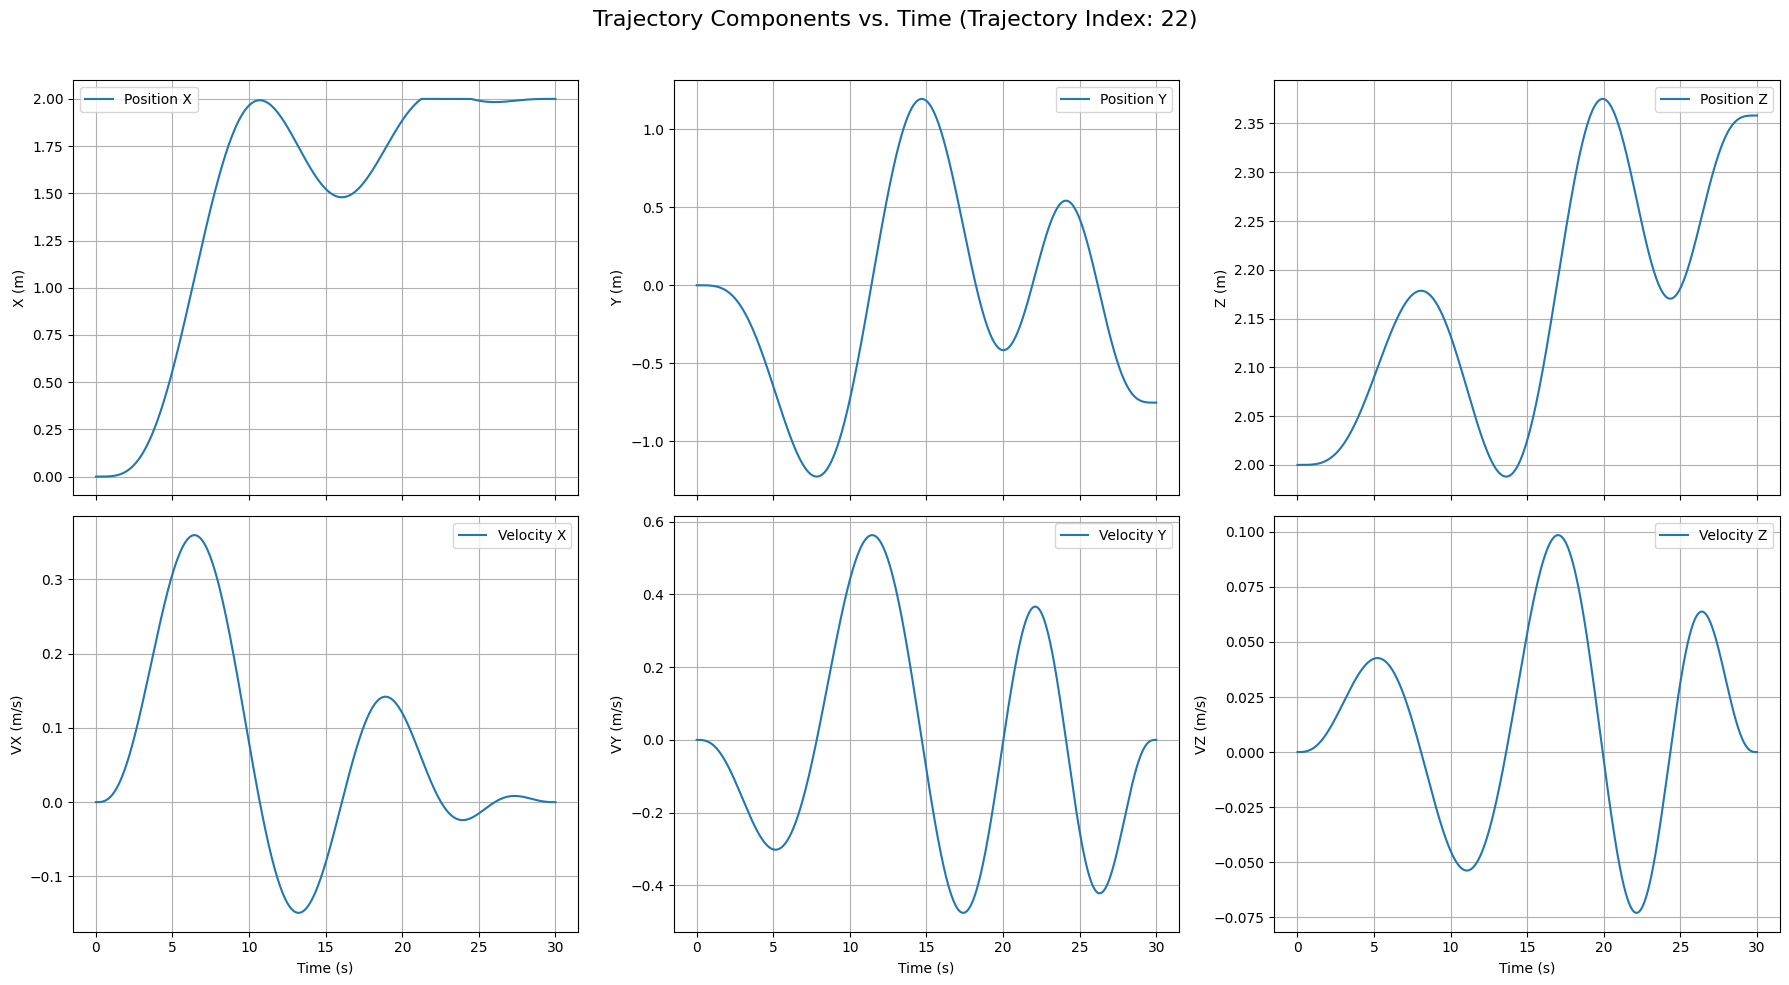

In [65]:
if trajectory is not None:
    fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
    fig.suptitle(f'Trajectory Components vs. Time (Trajectory Index: {trajectory_idx_to_plot})', fontsize=16)

    # Position plots
    axs[0, 0].plot(time, pos_x, label='Position X')
    axs[0, 0].set_ylabel('X (m)')
    axs[0, 0].legend()

    axs[0, 1].plot(time, pos_y, label='Position Y')
    axs[0, 1].set_ylabel('Y (m)')
    axs[0, 1].legend()

    axs[0, 2].plot(time, pos_z, label='Position Z')
    axs[0, 2].set_ylabel('Z (m)')
    axs[0, 2].legend()

    # Velocity plots
    axs[1, 0].plot(time, vel_x, label='Velocity X')
    axs[1, 0].set_ylabel('VX (m/s)')
    axs[1, 0].set_xlabel('Time (s)')
    axs[1, 0].legend()

    axs[1, 1].plot(time, vel_y, label='Velocity Y')
    axs[1, 1].set_ylabel('VY (m/s)')
    axs[1, 1].set_xlabel('Time (s)')
    axs[1, 1].legend()

    axs[1, 2].plot(time, vel_z, label='Velocity Z')
    axs[1, 2].set_ylabel('VZ (m/s)')
    axs[1, 2].set_xlabel('Time (s)')
    axs[1, 2].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
else:
    print("Trajectory data not loaded or selected. Skipping Plot 1.")

## 4. Plot 2: 3D Trajectory Path

Visualizes the overall path in 3D space.

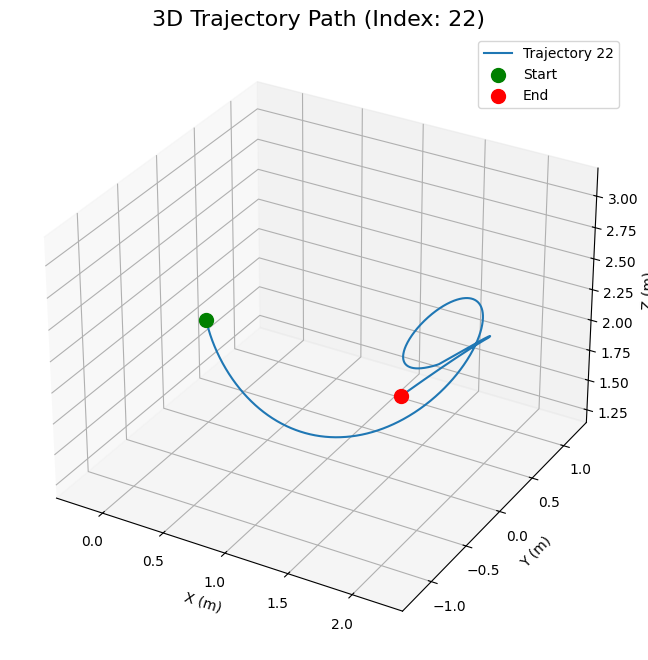

In [66]:
if trajectory is not None:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(pos_x, pos_y, pos_z, label=f'Trajectory {trajectory_idx_to_plot}')
    ax.scatter(pos_x[0], pos_y[0], pos_z[0], color='green', s=100, label='Start', depthshade=True)
    ax.scatter(pos_x[-1], pos_y[-1], pos_z[-1], color='red', s=100, label='End', depthshade=True)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title(f'3D Trajectory Path (Index: {trajectory_idx_to_plot})', fontsize=16)
    ax.legend()
    ax.axis('equal') # Aspect ratio
    plt.show()
else:
    print("Trajectory data not loaded or selected. Skipping 3D plot.")

## 5. Plot 3: XY Trajectory with Yaw Vectors

This plot shows the 2D path in the XY plane and overlays arrows (vectors) representing the desired yaw angle (`psi`) at sampled points. This helps verify if the yaw is correctly aligned with the direction of motion.

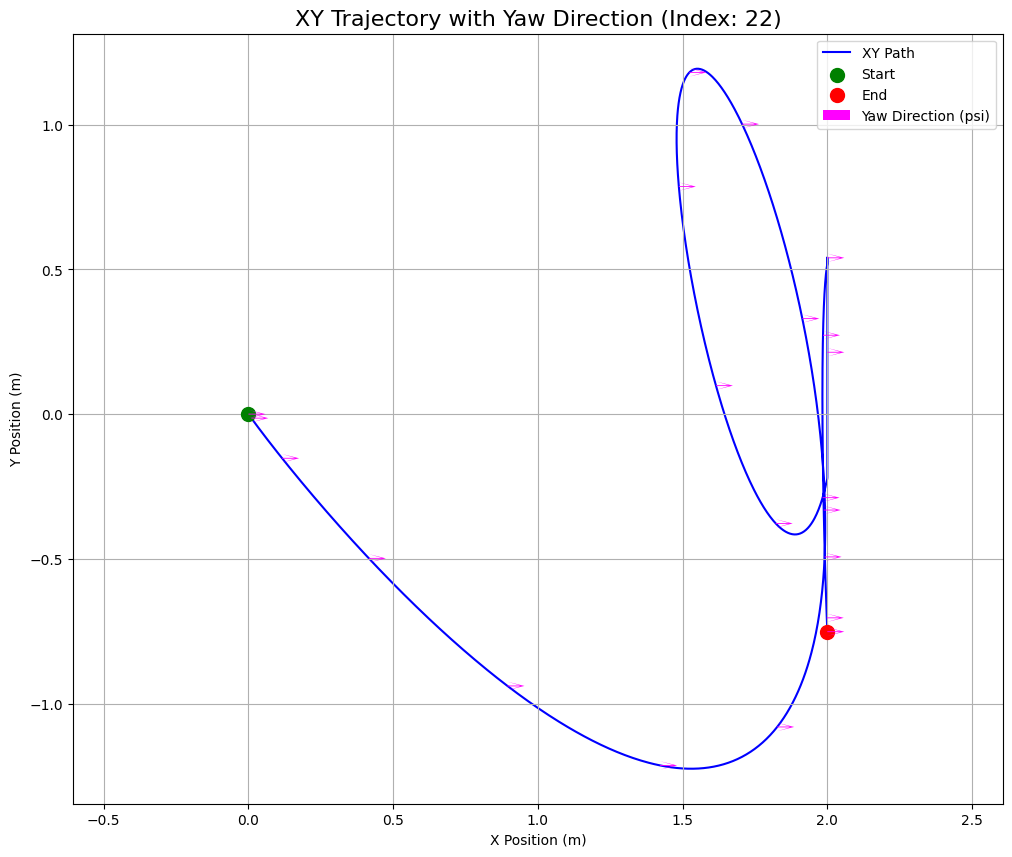

In [67]:
if trajectory is not None:
    plt.figure(figsize=(12, 10))
    plt.plot(pos_x, pos_y, label='XY Path', color='blue', zorder=1)
    plt.scatter(pos_x[0], pos_y[0], color='green', s=100, label='Start', zorder=2)
    plt.scatter(pos_x[-1], pos_y[-1], color='red', s=100, label='End', zorder=2)

    # Plot yaw vectors (quiver plot)
    # Select a subset of points to avoid cluttering the plot with too many arrows
    num_arrows = 20 
    step = max(1, len(time) // num_arrows)
    
    # Arrow properties
    arrow_length_scale = 10 # Adjust to make arrows a reasonable size relative to trajectory scale
    # Calculate arrow length based on average segment length or fixed value
    if len(pos_x) > 1:
        avg_segment_length = np.mean(np.sqrt(np.diff(pos_x)**2 + np.diff(pos_y)**2))
        arrow_length = avg_segment_length * arrow_length_scale 
        if arrow_length == 0: arrow_length = 0.1 # Fallback if segments are zero length
    else:
        arrow_length = 0.1 # Default arrow length if only one point
        
    # Ensure arrow_length is positive
    arrow_length = max(arrow_length, 0.01) 

    quiver_x = pos_x[::step]
    quiver_y = pos_y[::step]
    quiver_psi = psi[::step]
    
    # Components of the yaw vector
    # U = arrow_length * cos(psi)
    # V = arrow_length * sin(psi)
    quiver_u = arrow_length * np.cos(quiver_psi)
    quiver_v = arrow_length * np.sin(quiver_psi)
    
    plt.quiver(quiver_x, quiver_y, quiver_u, quiver_v, 
                   angles='xy', scale_units='xy', scale=1, # U,V are in data units
                   color='magenta', 
                   width=0.01, # Width of the arrow shaft
                   headwidth=10,     # Width of the arrow head in points
                   headlength=20,   # Length of the arrow head in points
                   headaxislength=6*0.8, # Length of the head at the arrow tip
                   zorder=3, 
                   label='Yaw Direction (psi)')

    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')
    plt.title(f'XY Trajectory with Yaw Direction (Index: {trajectory_idx_to_plot})', fontsize=16)
    plt.axis('equal')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Trajectory data not loaded or selected. Skipping Plot 2.")

## 6. Plot 4: Yaw (psi) vs. Time

Shows how the desired yaw angle changes over the duration of the trajectory.

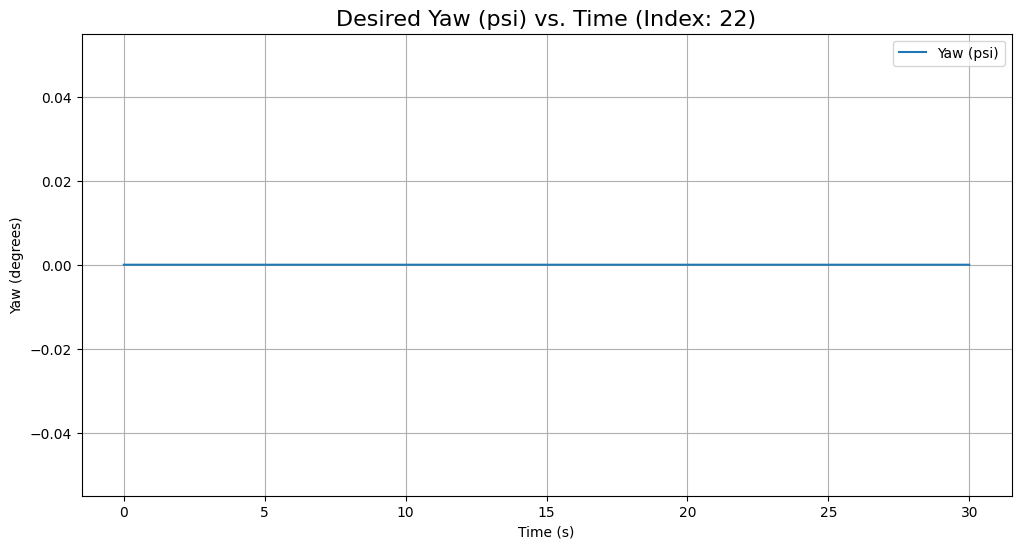

In [68]:
if trajectory is not None:
    plt.figure(figsize=(12, 6))
    plt.plot(time, np.rad2deg(psi), label='Yaw (psi)') # Plot in degrees for easier interpretation
    plt.xlabel('Time (s)')
    plt.ylabel('Yaw (degrees)')
    plt.title(f'Desired Yaw (psi) vs. Time (Index: {trajectory_idx_to_plot})', fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Trajectory data not loaded or selected. Skipping Plot 3.")